### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle as pkl
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

#### separate the features and target columnn.

In [2]:
dataset = pd.read_csv("processed table.csv")
dataset.drop(['Unnamed: 0'],axis=1,inplace=True)
dataset = pd.DataFrame(dataset)
y = dataset["Attrition"]
x = dataset.drop("Attrition",axis=1)

### Splitting data into train & test set

In [3]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [4]:
x_train.shape

(1176, 31)

In [5]:
x_test.shape

(294, 31)

In [6]:
y_train.shape

(1176,)

In [7]:
y_test.shape

(294,)

### Logistic Regression

In [8]:
lr=LogisticRegression(C = 0.1, random_state = 42, solver = 'liblinear')
dt=DecisionTreeClassifier()
rm=RandomForestClassifier()
gnb=GaussianNB()
knn = KNeighborsClassifier(n_neighbors=3)
svm = svm.SVC(kernel='linear')

In [9]:
for a,b in zip([lr,dt,knn,svm,rm,gnb],["Logistic Regression","Decision Tree","KNN","SVM","Random Forest","Naive Bayes"]):
    a.fit(x_train,y_train)
    prediction=a.predict(x_train)
    y_pred=a.predict(x_test)
    score1=accuracy_score(y_train,prediction)
    score=accuracy_score(y_test,y_pred)
    msg1="[%s] training data accuracy is : %f" % (b,score1)
    msg2="[%s] test data accuracy is : %f" % (b,score)
    print(msg1)
    print(msg2)

[Logistic Regression] training data accuracy is : 0.857993
[Logistic Regression] test data accuracy is : 0.870748
[Decision Tree] training data accuracy is : 1.000000
[Decision Tree] test data accuracy is : 0.792517
[KNN] training data accuracy is : 0.885204
[KNN] test data accuracy is : 0.812925
[SVM] training data accuracy is : 0.852891
[SVM] test data accuracy is : 0.867347
[Random Forest] training data accuracy is : 1.000000
[Random Forest] test data accuracy is : 0.877551
[Naive Bayes] training data accuracy is : 0.813776
[Naive Bayes] test data accuracy is : 0.840136


In [10]:
model_scores={'Logistic Regression':lr.score(x_test,y_test),
             'KNN classifier':knn.score(x_test,y_test),
             'Support Vector Machine':svm.score(x_test,y_test),
             'Random forest':rm.score(x_test,y_test),
              'Decision tree':dt.score(x_test,y_test),
              'Naive Bayes':gnb.score(x_test,y_test)
             }
model_scores

{'Logistic Regression': 0.8707482993197279,
 'KNN classifier': 0.8129251700680272,
 'Support Vector Machine': 0.8673469387755102,
 'Random forest': 0.8775510204081632,
 'Decision tree': 0.7925170068027211,
 'Naive Bayes': 0.8401360544217688}

### Classification from Logistic Regression

In [11]:
from sklearn.metrics import classification_report

lr_y_preds = lr.predict(x_test)

print(classification_report(y_test,lr_y_preds))

              precision    recall  f1-score   support

          No       0.88      0.98      0.93       255
         Yes       0.55      0.15      0.24        39

    accuracy                           0.87       294
   macro avg       0.71      0.57      0.58       294
weighted avg       0.84      0.87      0.84       294



### Classification from Random Forest

In [12]:

from sklearn.metrics import classification_report

rm_y_preds = rm.predict(x_test)

print(classification_report(y_test,rm_y_preds))

              precision    recall  f1-score   support

          No       0.88      1.00      0.93       255
         Yes       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



#### Model Comparison

In [13]:
model_compare=pd.DataFrame(model_scores,index=['accuracy'])
model_compare

,Logistic Regression,KNN classifier,Support Vector Machine,Random forest,Decision tree,Naive Bayes
accuracy,0.870748,0.812925,0.867347,0.877551,0.792517,0.840136


<Axes: >

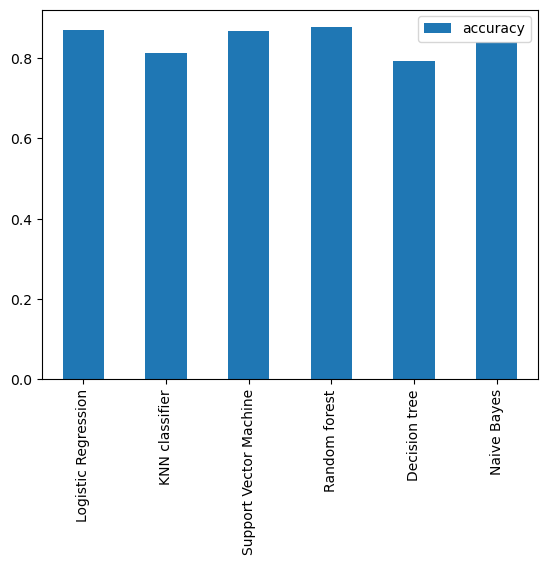

In [14]:
model_compare.T.plot(kind='bar') # (T is here for transpose)

- Random Forest has a better accuracy than Logistic regression but Random Forest is an overfitted model hence we will select Logistic regression.

#### Features and their Contribution in Logistic Regression

In [15]:
feature_dict=dict(zip(dataset.columns,list(lr.coef_[0])))
feature_dict

{'Age': -0.004803968519827291,
 'Attrition': -0.006560043796348598,
 'BusinessTravel': -1.4148667052068511e-05,
 'DailyRate': 0.30286300109662545,
 'Department': 0.03272161219759022,
 'DistanceFromHome': 0.09635208464106325,
 'Education': -0.058281178678590145,
 'EducationField': 5.36785518534118e-05,
 'EmployeeNumber': -0.2032761965436753,
 'EnvironmentSatisfaction': -0.09460621482533009,
 'Gender': 0.005381050865300697,
 'HourlyRate': -0.2184759071930046,
 'JobInvolvement': -0.03901633044543624,
 'JobLevel': 0.022854878023629763,
 'JobRole': -0.21717417817326132,
 'JobSatisfaction': -0.30756183671232074,
 'MaritalStatus': -8.973700085848842e-05,
 'MonthlyIncome': 1.756281480728559e-05,
 'MonthlyRate': 0.173359566704271,
 'NumCompaniesWorked': 0.8386281946310256,
 'OverTime': -0.005108950275184863,
 'PercentSalaryHike': 0.16861949818078414,
 'PerformanceRating': -0.043182619595727674,
 'RelationshipSatisfaction': -0.32844009675321423,
 'StockOptionLevel': -0.06266334916211318,
 'Total

<Axes: title={'center': 'Feature Importance'}>

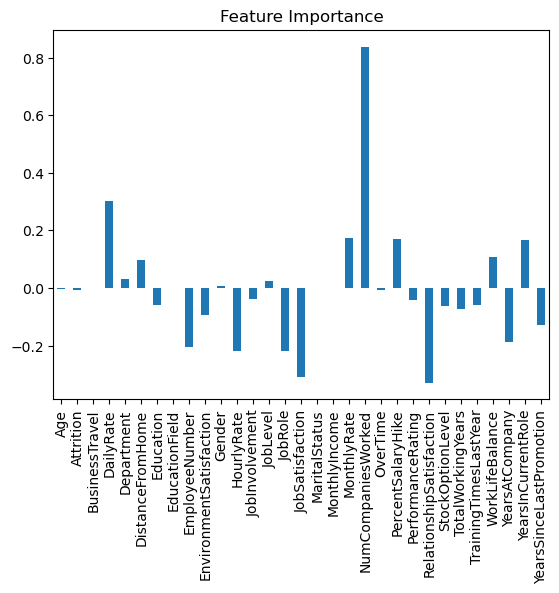

In [16]:
feature_df=pd.DataFrame(feature_dict,index=[0])
feature_df.T.plot(kind="bar",legend=False,title="Feature Importance")


- Number of companies worked is the biggest deciding factor

### Saving Model

In [17]:
save_model=pkl.dumps(lr)
lr_pkl=pkl.loads(save_model)
lr_pkl.predict(x_test)


array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', '